# 03. 기울기 소실 문제와 방지 기법

## 1. 역전파(Backpropagation)와 가중치 갱신

신경망은 순전파(Forward)로 예측값을 계산한 후, 출력층에서 발생한 오차를 역방향으로 거슬러 올라가며 가중치를 수정합니다.

- **오차의 전달 경로:** **`출력층(Output Layer) ──▶ 은닉층(Hidden Layer) ──▶ 입력층(Input Layer)`**
- **연쇄 법칙(Chain Rule):** 앞단(입력층에 가까운 층)의 가중치 기울기(Gradient)를 구하기 위해서는, 미적분의 연쇄 법칙에 의해 **출력층에 가까운 뒤쪽 레이어들이 계산해 놓은 기울기 값들을 계속해서 곱해와야 합니다.**

---

## 2. 기울기 소실(Vanishing Gradient)의 원인: Sigmoid

시그모이드(Sigmoid) 함수는 초기 신경망의 은닉층에 자주 사용되었으나, 망이 깊어질 수록 학습을 완전히 멈추게 만드는 치명적인 결함이 있습니다.

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

$$\sigma'(x) = \sigma(x)(1 - \sigma(x)) \quad (\text{미분 최댓값 } = 0.25)$$

* **그래디언트 포화 (Gradient Saturation):** 입력값($x$)이 조금만 커지거나 작아져도 함수의 기울기(미분값)가 **0**에 극도로 가까워집니다.
* **연쇄 곱셈의 비극:** 시그모이드 미분값의 최댓값은 겨우 `0.25`입니다. 역전파 과정에서 층을 하나 거칠 때마다 최소 4분의 1 토막 이하로 기울기가 줄어들며, 층이 7~8개만 되어도 앞단 레이어에 도달하는 기울기는 사실상 0이 되어 가중치 업데이트가 완전히 멈춰버립니다.

---

## 3. 해결책: 대안 활성화 함수(Activation Functions)

기울기 소실 문제를 극복하기 위해 현대 딥러닝에서는 은닉층에 시그모이드 대신 아래의 함수들을 조합하여 사용합니다.

### ① ReLU (Rectified Linear Unit) — 현대 딥러닝의 표준 은닉층 함수

입력값이 양수이기만 하면 기울기를 완벽하게 보존하여 깊은 신경망 학습을 가능하게 만든 일등공신입니다.

$$\text{ReLU}(x) = \max(0, x)$$

* **특징:** 입력값이 0보다 크면 ($x \ge 0$) 미분값은 항상 `1`입니다.
* **장점:** 연쇄 법칙에 의해 1은 아무리 여러 번 곱해도 오차가 줄어들지 않고 앞단 레이어까지 온전하게 전달되므로, **기울기 소실 문제가 근본적으로 해결**됩니다. 연산 속도 또한 매우 빠릅니다.

### ② Tanh (Hyperbolic Tangent) — 0을 중심으로 하는 쌍곡선 함수

시그모이드 함수의 출력값이 항상 양수여서 발생하는 '양수 편향(Non-zero centered)' 문제를 해결하기 위해 도입된 함수입니다.

$$\tanh(x) = \frac{e^{2x} - 1}{e^{2x} + 1}$$

* **특징:** 출력값의 범위가 $-1 \sim 1$이며, 중심이 **0**에 위치합니다.
* **장점 및 한계:** 시그모이드보다 학습 수렴 속도가 빠르고 양수 편향이 없지만, 미분 최댓값이 `1`일 뿐 양끝으로 갈수록 여전히 기울기가 0으로 죽는 성질이 있습니다. 따라서 깊은 은닉층에서는 ReLU를 주로 쓰고, 특정 구조(예: LSTM/GRU 같은 RNN 계열)나 상황에 맞춰 보조적으로 조합합니다.

---

> **핵심 요약**
> - **역전파**는 미분값을 **계속 곱하며** 앞으로 나아가는 과정입니다.
> - **Sigmoid**는 미분값이 너무 작아($\le 0.25$) 곱할수록 기울기가 사라지는 **기울기 소실**을 유발합니다.
> - 이를 해결하기 위해 미분값이 항상 1로 유지되는 **ReLU**를 은닉층의 표준으로 사용합니다.


## 0. 환경 설정


In [1]:
# Colab에는 TensorFlow가 기본 설치되어 있습니다.
import sys
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

import seaborn as sns

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# matplotlib 및 seaborn의 기본 설정을 변경합니다 (한글 깨짐 방지, 마이너스 부호 깨짐 방지, 고해상도 설정)
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))



Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

## 1) 활성화 함수와 도함수 보기



### 1. 왼쪽 그래프 (활성화 함수 원형)

- **Sigmoid (분홍색):** $0 \sim 1$ 사이의 부드러운 S자 곡선을 그리며, 원점($x=0$)에서 정확히 $0.5$를 지납니다.
- **Tanh (연두색):** $-1 \sim 1$ 사이를 오가며, 원점($x=0$)에서 정확히 $0$을 지납니다. Sigmoid보다 경사가 더 가파른 것도 정상입니다.
- **ReLU (파란색):** 음수 영역에서는 완전히 $0$으로 죽어 있다가, $x \ge 0$이 되는 순간부터 $y = x$의 직선을 그리며 $6$까지 뻗어 나갑니다.

---

### 2. 오른쪽 그래프 (도함수/기울기)

- **Sigmoid' (분홍색):** 종 모양(Bell-curve)을 그리며, 원점($x=0$)에서 최댓값 $0.25$를 찍고 양끝으로 갈수록 빠르게 $0$으로 수렴합니다.
- 하단의 출력문(`Sigmoid 도함수 최댓값 ≈ 0.2500`)과도 일치합니다. 이 부분이 **기울기 소실(Vanishing Gradient)의 주범**입니다.

- **Tanh' (연두색):** 역시 종 모양이지만 원점에서 최댓값 $1.0$을 찍습니다. 시그모이드보다 중심부 기울기는 훨씬 좋지만, 결국 $\pm 3$만 넘어가도 기울기가 $0$이 되는 한계가 눈에 보입니다.
- **ReLU' (파란색):** 음수 영역에서는 기울기가 $0$이고, **양수 영역에서는 높이 $1.0$을 유지**합니다.



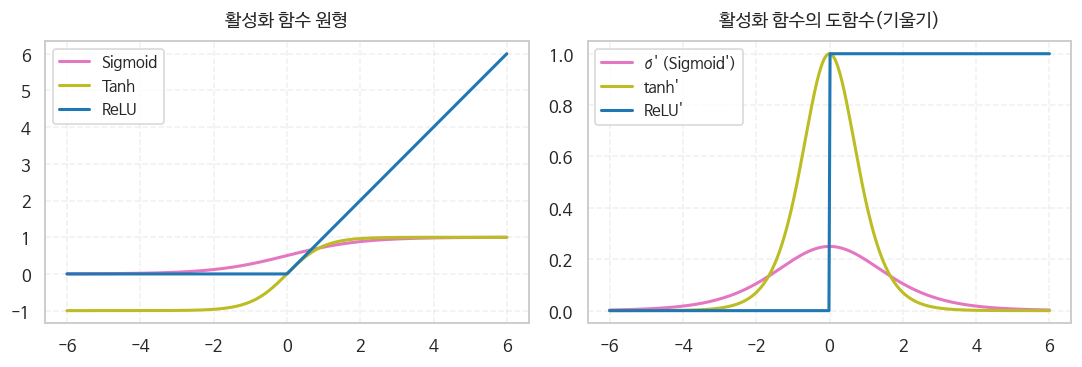

Sigmoid 도함수 최댓값 ≈ 0.2500  (이론적 최댓값: 0.25)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 한글 깨짐 방지 설정 (필요 시 주석 해제)
# plt.rc('font', family='Malgun Gothic') # Windows
# plt.rc('font', family='AppleGothic')   # Mac
# plt.rcParams['axes.unicode_minus'] = False

# ----------------------------------------------------
# 0. 입력 데이터 생성 (연속적인 실수 범위)
# ----------------------------------------------------
# -6.0부터 6.0까지 균일한 간격으로 400개의 1차원 데이터 생성
x = tf.linspace(-6.0, 6.0, 400)


# ----------------------------------------------------
# 1. tf.GradientTape를 활용한 활성화 함수별 도함수(기울기) 계산
# ----------------------------------------------------
# tf.Variable이 아닌 일반 상수 텐서는 tape.watch()로 추적 대상을 명시해야 미분이 가능합니다.

# --- [1] Sigmoid 함수 및 도함수 ---
with tf.GradientTape() as tape:
    tape.watch(x)
    y_sig = tf.nn.sigmoid(x)       # 순전파: Sigmoid 연산
d_sig = tape.gradient(y_sig, x)    # 역전파: dy_sig / dx (기울기 계산)

# --- [2] Tanh 함수 및 도함수 ---
with tf.GradientTape() as tape:
    tape.watch(x)
    y_tanh = tf.nn.tanh(x)         # 순전파: Tanh 연산
d_tanh = tape.gradient(y_tanh, x)  # 역전파: dy_tanh / dx

# --- [3] ReLU 함수 및 도함수 ---
with tf.GradientTape() as tape:
    tape.watch(x)
    y_relu = tf.nn.relu(x)         # 순전파: ReLU 연산
d_relu = tape.gradient(y_relu, x)  # 역전파: dy_relu / dx


# ----------------------------------------------------
# 2. fig, axes를 활용한 비교 시각화 (1행 2열)
# ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# --- 왼쪽 그래프: 활성화 함수 원본 형태 (Activation Functions) ---
axes[0].plot(x, y_sig, label="Sigmoid", color='#e377c2', linewidth=2)
axes[0].plot(x, y_tanh, label="Tanh", color='#bcbd22', linewidth=2)
axes[0].plot(x, y_relu, label="ReLU", color='#1f77b4', linewidth=2)
axes[0].set_title("활성화 함수 원형", fontsize=12, pad=10)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, linestyle="--")

# --- 오른쪽 그래프: 활성화 함수의 도함수 (Derivatives / Gradients) ---
# (역전파 때 실질적으로 앞단 레이어에 곱해져 전달되는 기울기의 크기를 뜻함)
axes[1].plot(x, d_sig, label="σ' (Sigmoid')", color='#e377c2', linewidth=2)
axes[1].plot(x, d_tanh, label="tanh'", color='#bcbd22', linewidth=2)
axes[1].plot(x, d_relu, label="ReLU'", color='#1f77b4', linewidth=2)
axes[1].set_title("활성화 함수의 도함수(기울기)", fontsize=12, pad=10)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, linestyle="--")

# 여백 조절 및 출력
fig.tight_layout()
plt.show()


# ----------------------------------------------------
# 3. 정량적 수치 검증 출력
# ----------------------------------------------------
# 계산된 Sigmoid 도함수 텐서의 최댓값을 출력하여 이론값(0.25)과 일치하는지 확인
print(f"Sigmoid 도함수 최댓값 ≈ {float(tf.reduce_max(d_sig)):.4f}  (이론적 최댓값: 0.25)")

## 2) Sigmoid vs ReLU 학습 비교

### 3줄 요약

- **Sigmoid (파란색):** 기울기 소실로 인해 학습이 완전히 불가능했습니다. (정확도 약 49% = 찍기 수준)
- **Tanh (주황색):** 원점 중심 설계 덕분에 선방했으나 ReLU보다는 수렴 속도와 최종 성능이 살짝 쳐집니다. (정확도 96.3%)
- **ReLU (초록색):** 기울기를 보존하는 특성 덕분에 가장 빠르고 완벽하게 정답을 찾아냈습니다. (정확도 98.3%)

---

### 활성화 함수별 심층 분석

#### 1. Sigmoid (`final acc = 0.493`) => 기울기 소실의 처참한 결과

- **현상:** 바닥(정확도 0.5 미만)에서 시작하여 35 에포크 내내 완전한 일직선(Flatline)을 그립니다.
- **해석:** 이진 분류에서 정확도 50% 수준이라는 것은 모델이 학습을 전혀 하지 못하고 동전 던지기(무작위 찍기)를 하고 있다는 뜻입니다.
- **이유:** 시그모이드의 도함수 최댓값은 `0.25`입니다. 8개의 층을 거치며 $0.25 \times 0.25 \times \dots$로 기울기가 연쇄적으로 곱해지자, 입력층에 도달한 기울기가 사실상 `0`이 되어 가중치 업데이트가 전면 중단(소실)된 것입니다.

#### 2. Tanh (`final acc = 0.963`) => 원점 중심(Zero-centered) 효과로 선방

- **현상:** 초반부터 빠르게 상승하여 최종적으로 96.3%라는 우수한 정확도에 도달했습니다.
- **해석:** 시그모이드와 같은 종 모양 도함수를 가졌음에도 학습에 성공했습니다. 원점($x=0$)에서의 기울기 최댓값이 `1.0`이며, 출력값이 음수와 양수를 모두 지원하여 시그모이드의 양수 편향 문제를 해결했기 때문입니다.
- **한계:** 데이터가 단순하여 이번에는 수렴했지만, ReLU(초록색) 곡선보다 항상 아래쪽에 위치하며 초반 상승세가 상대적으로 완만합니다. 층이 8층보다 더 깊어지거나 데이터가 복잡해지면 Tanh 역시 양끝단에서 기울기가 0으로 죽는 '포화 현상' 때문에 결국 무너졌을 것입니다.

#### 3. ReLU (`final acc = 0.983`) => 현대 딥러닝 표준의 압도적 증명

- **현상:** 학습 시작과 동시에 가장 가파른 경사를 그리며 치고 올라가며, 전 구간에서 가장 높은 정확도를 유지해 **98.3%로 우승**했습니다.
- **해석:** 데이터의 비선형 규칙을 가장 빠르고 정확하게 찾아냈습니다.
- **이유:** ReLU는 입력이 양수이기만 하면 도함수가 칼같이 `1.0`입니다. 연쇄 법칙으로 1을 8번 곱해도 오차 에너지가 $100\%$($1.0$) 그대로 보존되어 1층 은닉층까지 완벽하게 배달됩니다. 깊은 망에서도 가중치들이 아무런 막힘없이 팍팍 업데이트된 비결입니다.

---

#### 최종 결론

> 이 실험 결과는 **"신경망의 층이 깊어질 때(`Deep`), 은닉층 활성화 함수로 Sigmoid를 쓰는 것은 금기이며, 반드시 ReLU 계열을 채택해야 정상적인 학습을 보장할 수 있다"** 는 딥러닝의 기초 설계 공식을 눈으로 직접 증명해 줍니다.


sigmoid final acc = 0.493
tanh    final acc = 0.963
relu    final acc = 0.983


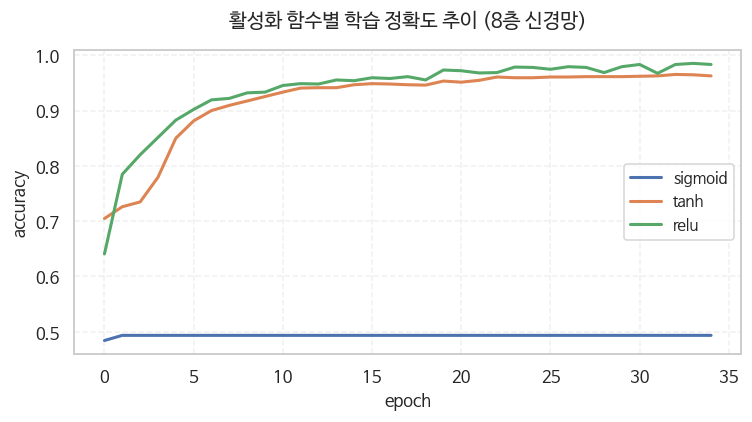

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ----------------------------------------------------
# 1. 4차원 입력의 비선형 분류 데이터셋 생성
# ----------------------------------------------------
n = 1500
# 평균 0, 표준편차 1인 4차원 특성 데이터 1,500개 생성
X = np.random.randn(n, 4).astype("float32")

# x0, x1의 곱과 x2의 선형 결합이 0보다 크면 1, 아니면 0으로 레이블링
# 단순 직선으로 나눌 수 없는 복잡한 비선형 경계를 가진 이진 분류 데이터입니다.
y = ((X[:, 0] * X[:, 1] + 0.5 * X[:, 2]) > 0).astype("float32")


# ----------------------------------------------------
# 2. 깊은 신경망(8층) 빌드 함수 정의
# ----------------------------------------------------
def deep_net(activation, depth=8):
    """
    지정된 활성화 함수를 사용하여 총 8층(은닉층 8개 + 출력층 1개)의 깊은 망을 구성합니다.
    최신 Keras 표준(UserWarning 방지)에 맞춰 layers.Input을 첫 단에 적용했습니다.
    """
    m = keras.Sequential()
    m.add(layers.Input(shape=(4,))) # 4차원 입력을 받는 입력층 독립 선언

    # 기울기 소실이 극적으로 일어나도록 은닉층을 8층까지 깊게 쌓음 (각 층 노드 32개)
    for _ in range(depth):
        m.add(layers.Dense(32, activation=activation))

    # 최종 이진 분류 결과를 확률(0~1)로 출력하는 출력층
    m.add(layers.Dense(1, activation="sigmoid"))

    # 고정 학습률 0.1의 SGD 옵티마이저와 크로스엔트로피 손실 함수 설정
    m.compile(optimizer=keras.optimizers.SGD(0.1), loss="binary_crossentropy", metrics=["accuracy"])
    return m


# ----------------------------------------------------
# 3. 활성화 함수별(Sigmoid, Tanh, ReLU) 루프 학습 진행
# ----------------------------------------------------
histories = {}

for act in ["sigmoid", "tanh", "relu"]:
    # 8층 깊이의 모델을 생성하여 35 에포크 동안 학습
    h = deep_net(act).fit(X, y, epochs=35, batch_size=64, verbose=0)

    # 시각화를 위해 에포크별 훈련 정확도(accuracy) 기록
    histories[act] = h.history["accuracy"]

    # 각 활성화 함수별 최종 에포크의 정확도를 콘솔에 출력
    print(f"{act:7s} final acc = {h.history['accuracy'][-1]:.3f}")


# ----------------------------------------------------
# 4. 학습 곡선(정확도 추이) 시각화
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))

for act, acc in histories.items():
    ax.plot(acc, label=act, linewidth=2)

ax.set_title("활성화 함수별 학습 정확도 추이 (8층 신경망)", fontsize=13, pad=15)
ax.set_xlabel("epoch", fontsize=11)
ax.set_ylabel("accuracy", fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle="--")

fig.tight_layout()
plt.show()

## 코드 작성 팁
- **은닉층**: ReLU (가장 기본)
- **출력층**: 이진분류 `sigmoid`, 다중분류 `softmax`, 회귀는 선형/`tanh` 등
- 깊은 은닉층에 Sigmoid만 쓰면 기울기 소실 위험이 큽니다.
